# 1. Simulación de Datos Financieros Sintéticos (FinanceAI v2.0)

Este cuaderno implementa la generación de datos transaccionales y de usuarios realistas para **11 categorías de gasto financiero** (incorporando *Créditos y Deudas*).

### Objetivos:
1. **Simular usuarios** con ingresos, deudas y un perfil de salud financiera basado en lógica difusa (ponderación de variables continuas y ruido gaussiano).
2. **Simular extractos bancarios para 11 categorías** con variedad léxica, formato bancario ISO y montos escalados según el poder adquisitivo del cliente (`factor_ingreso`).
3. **Modelar una partición temporal (Out-of-Time)** asignando ventanas cronológicas sintéticas asociadas a los subconjuntos (`train`, `val`, `test`) para simular la llegada progresiva de transacciones sin alterar la representatividad léxica.


In [1]:
# =============================================================================
# 1. IMPORTACION DE LIBRERIAS Y CONFIGURACION DEL ENTORNO
# =============================================================================
# 'os' permite interactuar con el sistema operativo (crear carpetas, rutas).
import os

# 'random' provee funciones para generacion de numeros y elecciones pseudoaleatorias.
import random

# 'datetime', 'timedelta' y 'timezone' permiten manipular fechas con zona horaria.
from datetime import datetime, timedelta, timezone

# 'matplotlib.pyplot' y 'seaborn' son librerias para visualizacion de datos estadisticos.
import matplotlib.pyplot as plt

# 'numpy' facilita calculos numericos y distribuciones probabilisticas continuas.
import numpy as np

# 'pandas' es la estructura central para manipular tablas de datos (DataFrames).
import pandas as pd
import seaborn as sns

# Establecemos un tema visual limpio con rejilla blanca para todos los graficos
sns.set_theme(style="whitegrid")

# FIJACION DE SEMILLA PSEUDOALEATORIA (REPRODUCIBILIDAD):
# Fijar SEED = 42 asegura que cualquier persona que ejecute este cuaderno obtenga
# exactamente los mismos datos sinteticos, garantizando reproducibilidad cientifica.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Definimos el directorio relativo donde se almacenaran los archivos CSV generados
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)  # Crea la carpeta 'data/' si todavia no existe
print("Entorno inicializado correctamente con semilla fija.")


Entorno inicializado correctamente con semilla fija.


## 1.1 Simulación del Padrón de Usuarios y Salud Financiera

En lugar de asignar perfiles (Saludable, En riesgo) con reglas rígidas, calculamos un score continuo agregando ruido gaussiano. Esto crea una zona gris realista donde el modelo deberá aprender a interpolar.

In [2]:
# =============================================================================
# 2. MOTOR DE LOGICA DIFUSA PARA SALUD FINANCIERA (PADRON DE USUARIOS)
# =============================================================================

def asignar_perfil_financiero(ingreso, nivel_endeudamiento, frecuencia_ahorro, noise_std=0.05):
    """
    Calcula el perfil de riesgo crediticio de un usuario combinando sus variables financieras.
    En lugar de usar un arbol de decisiones rigido (if/else estricto), usamos una funcion
    continua ponderada mas un 'ruido gaussiano'. Esto crea una 'zona gris' realista donde
    usuarios con metricas similares pueden caer en perfiles adyacentes.
    """
    # 1. Normalizamos el nivel de endeudamiento a una escala de 0.0 a 1.0 (maximo 100% de deuda)
    score_endeudamiento = min(nivel_endeudamiento / 100.0, 1.0)
    
    # 2. Mapeamos la frecuencia de ahorro a una escala de riesgo: no ahorrar penaliza (1.0), ahorrar mucho favorece (0.0)
    score_ahorro = {"NINGUNA": 1.0, "BAJA": 0.65, "MEDIA": 0.35, "ALTA": 0.0}[frecuencia_ahorro]
    
    # 3. Normalizamos el ingreso: ingresos bajos aumentan el riesgo; ingresos >= $8000 dan riesgo 0
    score_ingreso = max(0.0, 1.0 - (ingreso / 8000.0))
    
    # 4. Ponderacion de variables basada en criterios bancarios estandares:
    #    - 45% peso al nivel de deuda (la capacidad de pago comprometida).
    #    - 40% peso al habito de ahorro (resiliencia ante imprevistos).
    #    - 15% peso al ingreso absoluto (capacidad bruta de generacion de flujo).
    score_riesgo = 0.45 * score_endeudamiento + 0.40 * score_ahorro + 0.15 * score_ingreso
    
    # 5. Inyeccion de Ruido Gaussiano: simula factores no observables (ej. historial oculto, gastos medicos)
    score_riesgo += np.random.normal(0, noise_std)
    score_riesgo = np.clip(score_riesgo, 0.0, 1.0)  # Restringimos el valor final estrictamente entre [0.0, 1.0]
    
    # 6. Clasificacion final segun umbrales de riesgo continuo
    if score_riesgo < 0.33:
        return "Saludable", score_riesgo
    elif score_riesgo < 0.60:
        return "En observacion", score_riesgo
    else:
        return "En riesgo", score_riesgo

# Parametros de simulacion de usuarios
num_usuarios = 1200
usuarios = []
frecuencias = ["NINGUNA", "BAJA", "MEDIA", "ALTA"]

# Generamos 1200 perfiles representativos del padron de clientes de FinanceAI
for i in range(1, num_usuarios + 1):
    # Distribucion triangular para ingresos: min=$800, moda=$3500, max=$7500 (refleja la distribucion salarial real)
    ingreso = round(np.random.triangular(800, 3500, 7500), 2)
    
    # Distribucion normal para endeudamiento: media=35%, desviacion=15%, acotado entre [5%, 80%]
    nivel_endeudamiento = round(max(5.0, min(80.0, np.random.normal(35, 15))), 2)
    
    # Eleccion aleatoria del habito de ahorro declarado
    frecuencia_ahorro = random.choice(frecuencias)
    
    # Asignamos el perfil segun la logica difusa definida
    perfil, score = asignar_perfil_financiero(ingreso, nivel_endeudamiento, frecuencia_ahorro)
    
    # Asignacion de particion para el padron de usuarios (70% Train, 15% Val, 15% Test)
    r = random.random()
    split = 'train' if r < 0.7 else ('val' if r < 0.85 else 'test')
        
    # Guardamos el registro completo del usuario
    usuarios.append({
        'id': i,
        'nombre': f"User_{i}",
        'email': f"user{i}@example.com",
        'ingreso_mensual': ingreso,
        'nivel_endeudamiento': nivel_endeudamiento,
        'frecuencia_ahorro': frecuencia_ahorro,
        'perfil_financiero': perfil,
        'score_riesgo_oculto': score,
        'split': split
    })

# Convertimos la lista de diccionarios en un DataFrame de Pandas y exportamos a CSV
df_u = pd.DataFrame(usuarios)
df_u.to_csv(f"{DATA_DIR}/usuarios.csv", index=False)
print(f"Se generaron {len(df_u)} usuarios exitosamente en '{DATA_DIR}/usuarios.csv'.")


Se generaron 1200 usuarios exitosamente en 'data/usuarios.csv'.


### Visualización: Distribución de Ingresos y Perfiles

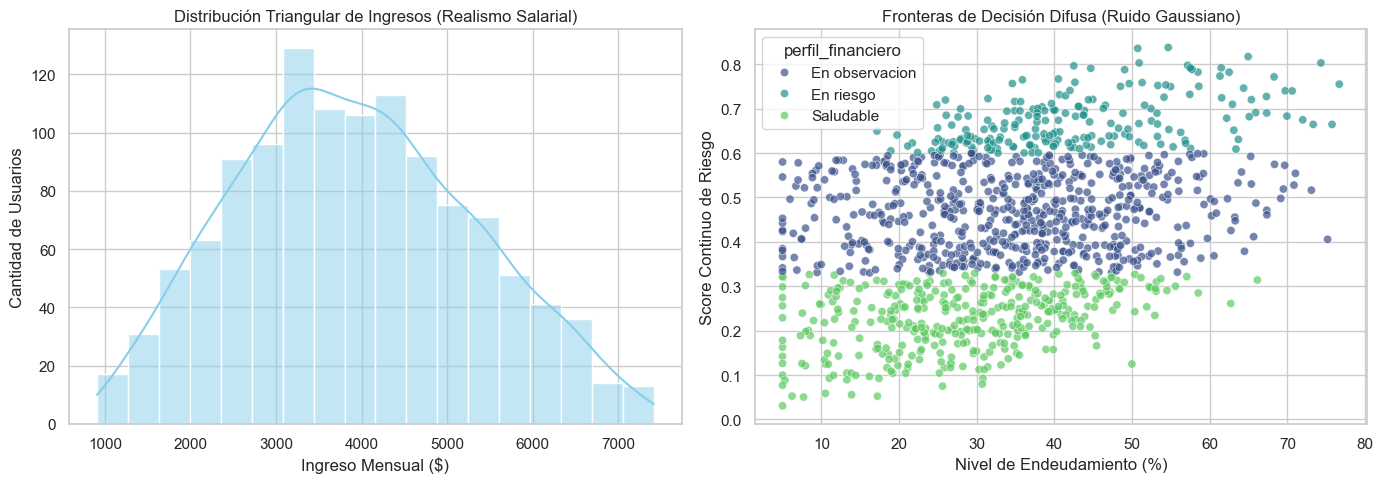

In [3]:
# =============================================================================
# 3. VISUALIZACION DE DISTRIBUCIONES DEMOGRAFICAS Y FRONTERAS DIFUSAS
# =============================================================================

# Creamos una figura con dos subgraficos dispuestos horizontalmente (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1 (Izquierda): Histograma con estimacion de densidad (KDE) para verificar la curva de ingresos
sns.histplot(df_u['ingreso_mensual'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribución Triangular de Ingresos (Realismo Salarial)')
ax[0].set_xlabel('Ingreso Mensual ($)')
ax[0].set_ylabel('Cantidad de Usuarios')

# Grafico 2 (Derecha): Diagrama de dispersion que demuestra el solapamiento realista en las fronteras de riesgo
sns.scatterplot(
    data=df_u,
    x='nivel_endeudamiento',
    y='score_riesgo_oculto',
    hue='perfil_financiero',
    palette='viridis',
    alpha=0.7,
    ax=ax[1]
)
ax[1].set_title('Fronteras de Decisión Difusa (Ruido Gaussiano)')
ax[1].set_xlabel('Nivel de Endeudamiento (%)')
ax[1].set_ylabel('Score Continuo de Riesgo')

plt.tight_layout()  # Ajusta margenes automaticamente para evitar solapamientos
plt.show()


## 1.2 Motor de Transacciones (11 Categorías NLP y Escalado Salarial)

Generaremos extractos bancarios combinando descripciones base ampliadas con formatos de terminal bancaria, sufijos, códigos de tarjeta, casos ambiguos controlados y escalado de montos según el ingreso mensual de cada usuario.

In [4]:
# =============================================================================
# 4. SIMULACION DE EXTRACTOS BANCARIOS CON COMPORTAMIENTO Y ESCALADO SALARIAL
# =============================================================================

# Rangos base de montos para las 11 categorías financieras
RANGOS_MONTO_V2 = {
    "Vivienda": (80, 2800),
    "Electrodomesticos": (50, 3200),
    "Alimentacion": (15, 800),
    "Servicios": (30, 600),
    "Educacion": (50, 600),
    "Salud": (20, 1200),
    "Inversion": (50, 2500),
    "Transporte": (10, 400),
    "Vestimenta": (20, 600),
    "Ocio": (15, 500),
    "Creditos y Deudas": (100, 3500)
}

# Diccionario enriquecido con variedad léxica del consumo real
DESCRIPCIONES_BASE = {
    "Vivienda": [
        "ALQUILER DEPARTAMENTO", "EXPENSAS CONSORCIO", "ADMINISTRACION TORRES", 
        "DEPOSITO GARANTIA ALQUILER", "PINTURERIA LATEX", "MANTENIMIENTO EDIFICIO", "INMOBILIARIA CONTRATO"
    ],
    "Electrodomesticos": [
        "FRAVEGA ELECTRO", "RODO HOGAR", "WHIRLPOOL LAVARROPAS", "SAMSUNG TV", 
        "HELADERA NO FROST", "MICROONDAS DIGITAL", "CASA DEL AUDIO", "MERCADO LIBRE"
    ],
    "Alimentacion": [
        "SUPERMERCADO COTO", "CARREFOUR EXPRESS", "SUPERMERCADO DIA", "DISCO", 
        "PANADERIA ARTESANAL", "CARNICERIA Y GRANJA", "MERCADITO VECINAL", 
        "ALMUERZO EJECUTIVO BODEGON", "VERDULERIA Y FRUTERIA"
    ],
    "Servicios": [
        "EDENOR ELECTRICIDAD", "METROGAS CONSUMO", "AYSA AGUA", "CONEXION FIBRA OPTICA", 
        "TELECENTRO INTERNET", "ABONO CELULAR PERSONAL", "CLARO FACTURA MENSUAL"
    ],
    "Educacion": [
        "UNIVERSIDAD CUOTA", "COLEGIO MENSUALIDAD", "MATERIAL ESTUDIO FOTOCOPIAS", 
        "CURSO INTENSIVO PROGRAMACION", "PLATZI EDUCACION", "UDEMY CURSO", "LIBRERIA ESCOLAR"
    ],
    "Salud": [
        "FARMACITY FARMACIA", "CLINICA MEDICA", "CONSULTA MEDICA DERMATOLOGO", 
        "ATENCION ODONTOLOGICA", "OSDE MEDICINA PREPAGA", "SWISS MEDICAL", "LABORATORIO BIOQUIMICO"
    ],
    "Inversion": [
        "BINANCE CRIPTO", "BALANZ INVERSIONES", "BULL MARKET BROKERS", 
        "COMPRA DOLARES MEP", "ADQUISICION BONOS SOBERANOS", "APERTURA PLAZO FIJO", "FONDO COMUN INVERSION"
    ],
    "Transporte": [
        "COMBUSTIBLE DIESEL YPF", "ESTACION SHELL", "CARGA AXION", "SUBE RECARGA", 
        "UBER VIAJE", "CABIFY AEROPUERTO", "PEAJE AUTOPISTA", "ESTACIONAMIENTO MEDIDO"
    ],
    "Vestimenta": [
        "ZARA MODA", "ADIDAS ORIGINAL", "NIKE DEPORTES", "ZAPATILLAS DEPORTIVAS", 
        "TIENDA INDUMENTARIA", "BUZO CON CAPUCHA", "REMERA ALGODON"
    ],
    "Ocio": [
        "CINE HOYTS TRASNOCHE", "ENTRADAS RECITAL ESTADIO", "RESTAURANTE GOURMET", 
        "SPOTIFY PREMIUM", "NETFLIX SUSCRIPCION", "BAR CERVECERIA", "TEATRO LOCAL"
    ],
    "Creditos y Deudas": [
        "PAGO TARJETA VISA", "PAGO RESUMEN MASTERCARD", "CUOTA PRESTAMO PERSONAL", 
        "AMORTIZACION CREDITO HIPOTECARIO", "ADELANTO DE SUELDO", "PAGO MINIMO TARJETA", 
        "FINANCIACION EN CUOTAS", "BANCO BBVA PRESTAMO", "BANCO SANTANDER TARJETA", "CREDITO AUTOMOTRIZ"
    ]
}

# Ambigüedad léxica entre categorías
AMBIGUOS_COMPARTIDOS = [
    ("FARMACITY", ["Salud", "Alimentacion"]),
    ("SUSCRIPCION MENSUAL", ["Ocio", "Educacion", "Servicios"]),
    ("PAGO CUOTA MENSUAL", ["Vivienda", "Servicios", "Educacion", "Creditos y Deudas"]),
    ("MERCADO LIBRE", ["Electrodomesticos", "Vestimenta", "Ocio"]),
    ("TRANSFERENCIA RECIBIDA", ["Inversion", "Servicios", "Vivienda", "Creditos y Deudas"]),
    ("DEBITO AUTOMATICO", ["Servicios", "Salud", "Ocio", "Creditos y Deudas"]),
    ("PAGO RESUMEN MENSUAL", ["Creditos y Deudas", "Servicios", "Vivienda"]),
    ("SUPERMERCADO", ["Alimentacion", "Electrodomesticos", "Vestimenta"])
]

# Formato bancario realista
CIUDADES = ["CABA", "CORDOBA", "ROSARIO", "MENDOZA", "LA PLATA", "MAR DEL PLATA", "ONLINE"]
CANALES = ["COMPRA TPV", "DB AUTOMATICO", "TRANSFERENCIA", "PAGO QR", "E-COMMERCE"]

def formatear_extracto_bancario(base_comercio):
    canal = random.choice(CANALES)
    ciudad = random.choice(CIUDADES)
    tarjeta = f"*{random.randint(1000, 9999)}"
    op_id = f"REF:{random.randint(100000, 999999)}"
    return f"{canal} {base_comercio} {ciudad} {tarjeta} {op_id}"

def generar_descripcion(cat):
    if random.random() < 0.25:
        candidatos = [a[0] for a in AMBIGUOS_COMPARTIDOS if cat in a[1]]
        base = random.choice(candidatos) if candidatos else random.choice(DESCRIPCIONES_BASE[cat])
    else:
        base = random.choice(DESCRIPCIONES_BASE[cat])
        
    desc = formatear_extracto_bancario(base)
    
    if random.random() < 0.05:
        desc = desc.replace("O", "0").replace("A", "4").replace("E", "3")
    return desc

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

def generar_fecha_con_estacionalidad(split, categoria):
    if split == 'train':
        fecha = random_date(datetime(2026, 1, 1, tzinfo=timezone.utc), datetime(2026, 8, 31, tzinfo=timezone.utc))
    elif split == 'val':
        fecha = random_date(datetime(2026, 9, 1, tzinfo=timezone.utc), datetime(2026, 10, 31, tzinfo=timezone.utc))
    else:
        fecha = random_date(datetime(2026, 11, 1, tzinfo=timezone.utc), datetime(2026, 12, 17, tzinfo=timezone.utc))
        
    # Vivienda, Servicios y Deudas se pagan preferentemente a principio de mes (días 1 al 10)
    if categoria in ["Vivienda", "Servicios", "Creditos y Deudas"] and random.random() < 0.70:
        dia_ajustado = min(random.randint(1, 10), 28)
        fecha = fecha.replace(day=dia_ajustado)
    return fecha

# -------------------------------------------------------------
# Matriz de probabilidad conductual para 11 categorías
# -------------------------------------------------------------
PROBABILIDADES_GASTO_POR_PERFIL = {
    "Saludable": {
        "Alimentacion": 0.16, "Vivienda": 0.14, "Servicios": 0.08,
        "Transporte": 0.08, "Educacion": 0.09, "Inversion": 0.16,
        "Salud": 0.05, "Vestimenta": 0.05, "Ocio": 0.07, 
        "Electrodomesticos": 0.04, "Creditos y Deudas": 0.08
    },
    "En observacion": {
        "Alimentacion": 0.22, "Vivienda": 0.22, "Servicios": 0.12,
        "Transporte": 0.09, "Educacion": 0.05, "Inversion": 0.02,
        "Salud": 0.05, "Vestimenta": 0.05, "Ocio": 0.03, 
        "Electrodomesticos": 0.04, "Creditos y Deudas": 0.11
    },
    "En riesgo": {
        "Alimentacion": 0.26, "Vivienda": 0.22, "Servicios": 0.16,
        "Transporte": 0.08, "Educacion": 0.01, "Inversion": 0.00,
        "Salud": 0.02, "Vestimenta": 0.01, "Ocio": 0.01, 
        "Electrodomesticos": 0.05, "Creditos y Deudas": 0.18
    }
}

def seleccionar_categoria_por_usuario(perfil_usuario):
    distribucion = PROBABILIDADES_GASTO_POR_PERFIL[perfil_usuario]
    categorias = list(distribucion.keys())
    pesos = list(distribucion.values())
    return random.choices(categorias, weights=pesos, k=1)[0]

# Función de escalado de montos por poder adquisitivo (factor_ingreso)
INGRESO_BASE = 3500.0

def calcular_monto_ajustado(cat, ingreso_usuario):
    m_min, m_max = RANGOS_MONTO_V2[cat]
    factor = max(0.6, min(ingreso_usuario / INGRESO_BASE, 2.5))
    
    if cat in ["Vivienda", "Ocio", "Vestimenta", "Inversion", "Creditos y Deudas", "Electrodomesticos"]:
        monto = random.uniform(m_min * factor, m_max * factor)
    else:
        monto = random.uniform(m_min, m_max * (1 + (factor - 1) * 0.35))
        
    return round(monto, 2)

# Generación basada en usuarios
transacciones = []
t_id = 1

for u in usuarios:
    num_tx = random.randint(15, 40)
    for _ in range(num_tx):
        cat = seleccionar_categoria_por_usuario(u['perfil_financiero'])
        
        r = random.random()
        split_tx = 'train' if r < 0.7 else ('val' if r < 0.85 else 'test')
        
        f = generar_fecha_con_estacionalidad(split_tx, cat)
        monto = calcular_monto_ajustado(cat, u['ingreso_mensual'])
        
        transacciones.append({
            'id': t_id,
            'usuario_id': u['id'],
            'descripcion': generar_descripcion(cat),
            'monto': monto,
            'categoria': cat,
            'fecha': f.strftime("%Y-%m-%d"),
            'split': split_tx
        })
        t_id += 1

random.shuffle(transacciones)

df_t = pd.DataFrame(transacciones)
df_t.to_csv(f"{DATA_DIR}/transacciones.csv", index=False)
print(f"Se generaron {len(df_t)} transacciones (11 categorias) con escalado por ingreso mensual.")
df_t.head()



Se generaron 33550 transacciones (11 categorias) con escalado por ingreso mensual.


,id,usuario_id,descripcion,monto,categoria,fecha,split
0,32104,1150,3-C0MM3RC3 C4RR3F0UR 3XPR3SS C0RD0B4 *4488 R3F...,595.36,Alimentacion,2026-09-13,val
1,4535,157,COMPRA TPV PAGO CUOTA MENSUAL MAR DEL PLATA *2...,2291.30,Vivienda,2026-05-16,train
2,18293,654,DB AUTOMATICO CARREFOUR EXPRESS ONLINE *5042 R...,328.31,Alimentacion,2026-07-13,train
3,32382,1160,PAGO QR DISCO CORDOBA *9465 REF:404710,49.02,Alimentacion,2026-02-26,train
4,18062,646,PAGO QR SUPERMERCADO DIA MENDOZA *5411 REF:777827,478.32,Alimentacion,2026-02-25,train


## 1.3 Conclusiones de la Simulación
Al implementar ambigüedad cruzada (`AMBIGUOS_COMPARTIDOS`) y un desbalance de clases controlado, hemos generado un dataset sintético que retendrá un nivel de dificultad realista (ruido bayesiano irresoluble de forma trivial) para nuestro clasificador semántico.